In [2]:
import dask_geopandas as dgpd
import geopandas as gpd
import rasterio
from rasterio.sample import sample_gen
from pathlib import Path
import numpy as np
import pandas as pd
import dask

In [2]:
import dask.dataframe as dd

In [3]:

df = dd.read_parquet("/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/data_icesat2/icesat2_features_for_model.parquet")
print(df.columns)
print(df.head())

Index(['region', 'sc_orient', 'track', 'segment_dist', 'solar_elevation',
       'segment_id', 'background_rate', 'cycle', 'pair', 'rgt', 'snowcover',
       'yapc_score', 'height', 'y_atc', 'landcover', 'x_atc', 'relief',
       'quality_ph', 'atl03_cnf', 'atl08_class', 'geometry', 'spot', 'time',
       'geoid_height', 'orthometric_height', 'h_alos_dem', 'delta_alos_dem',
       'abs_delta_alos_dem', 'h_aster_dem', 'delta_aster_dem',
       'abs_delta_aster_dem', 'h_copernicus_dеm', 'delta_copernicus_dеm',
       'abs_delta_copernicus_dеm', 'h_fab_dem', 'delta_fab_dem',
       'abs_delta_fab_dem', 'h_nasa_dem', 'delta_nasa_dem',
       'abs_delta_nasa_dem', 'h_srtm_dem', 'delta_srtm_dem',
       'abs_delta_srtm_dem', 'h_tan_dem', 'delta_tan_dem', 'abs_delta_tan_dem',
       'year', 'lulc_class', 'lulc_name', 'alos_dem_slope', 'aster_dem_slope',
       'copernicus_dеm_slope', 'fab_dem_slope', 'nasa_dem_slope',
       'srtm_dem_slope', 'tan_dem_slope', 'alos_dem_geomorphon',
       'al

In [4]:
floodplain = df[df["tan_dem_2000"] <= 5]
count = floodplain.shape[0].compute()
print(f"Точок у заплаві (tan_dem_2000 <= 5): {count}")


Точок у заплаві (tan_dem_2000 <= 5): 85183


In [ ]:
ice_gdf = gpd.read_parquet("/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/data_icesat2/icesat2_features_for_model.parquet")

In [3]:
filtered_2 = ice_gdf[
    (ice_gdf["atl03_cnf"] == 4) &
    (ice_gdf["atl08_class"].isin([1]))
    ]

In [ ]:
filtered_2.to_parquet(
    '/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/data_icesat2/icesat2_DEM_filterred_ground.parquet')

In [12]:
print(ice_gdf.head(1))


                               region  sc_orient  track  segment_dist  \
2018-11-04 01:05:31.626116096     6.0        1.0    1.0  1.472979e+07   

                               solar_elevation  segment_id  background_rate  \
2018-11-04 01:05:31.626116096       -40.574768    735401.0      2756.054548   

                               cycle  pair    rgt  ...  nasa_dem_stream  \
2018-11-04 01:05:31.626116096    1.0   0.0  556.0  ...       170.688569   

                               srtm_dem_stream  tan_dem_stream  alos_dem_twi  \
2018-11-04 01:05:31.626116096       170.688569      192.733835      5.623988   

                               aster_dem_twi  copernicus_dеm_twi  fab_dem_twi  \
2018-11-04 01:05:31.626116096       4.552485            5.088821     5.662695   

                               nasa_dem_twi  srtm_dem_twi  tan_dem_twi  
2018-11-04 01:05:31.626116096      4.363451      4.352303     5.088826  

[1 rows x 91 columns]


In [13]:
for col in ice_gdf.columns:
    print(col)

region
sc_orient
track
segment_dist
solar_elevation
segment_id
background_rate
cycle
pair
rgt
snowcover
yapc_score
height
y_atc
landcover
x_atc
relief
quality_ph
atl03_cnf
atl08_class
geometry
spot
time
geoid_height
orthometric_height
h_alos_dem
delta_alos_dem
abs_delta_alos_dem
h_aster_dem
delta_aster_dem
abs_delta_aster_dem
h_copernicus_dеm
delta_copernicus_dеm
abs_delta_copernicus_dеm
h_fab_dem
delta_fab_dem
abs_delta_fab_dem
h_nasa_dem
delta_nasa_dem
abs_delta_nasa_dem
h_srtm_dem
delta_srtm_dem
abs_delta_srtm_dem
h_tan_dem
delta_tan_dem
abs_delta_tan_dem
year
lulc_class
lulc_name
alos_dem_slope
aster_dem_slope
copernicus_dеm_slope
fab_dem_slope
nasa_dem_slope
srtm_dem_slope
tan_dem_slope
alos_dem_geomorphon
alos_dem_landform
aster_dem_geomorphon
aster_dem_landform
copernicus_dеm_geomorphon
copernicus_dеm_landform
fab_dem_geomorphon
fab_dem_landform
nasa_dem_geomorphon
nasa_dem_landform
srtm_dem_geomorphon
srtm_dem_landform
tan_dem_geomorphon
tan_dem_landform
alos_dem_2000
aster_dem

In [13]:
# Вибірка для декількох DEM:
floodplain_all = ice_gdf[
    (ice_gdf["hand_tan_dem"] <= 5) |
    (ice_gdf["hand_srtm_dem"] <= 5) |
    (ice_gdf["hand_fab_dem"] <= 5)
]
print(f"Точок у заплаві (будь-який DEM, <=5м): {len(floodplain_all)}")


Точок у заплаві (будь-який DEM, <=5м): 193919


<class 'pandas.core.frame.DataFrame'>
Точок у заплаві (tan_dem_2000 <= 5): 7312083


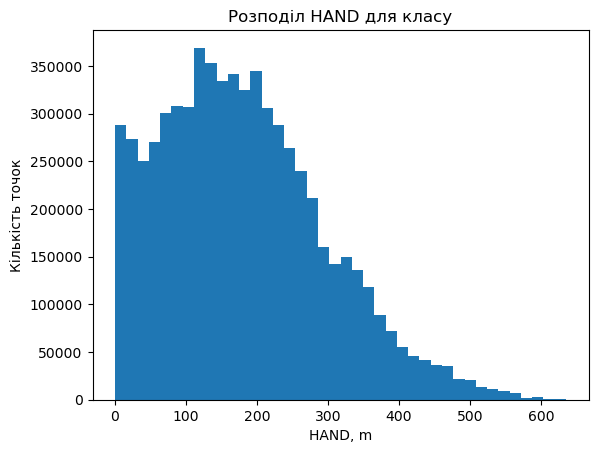

Точок у заплаві (tan_dem_2000 <= 5): 2022807


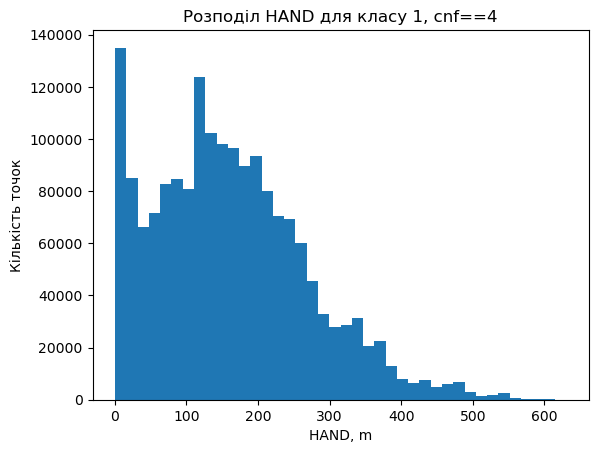

In [7]:
import matplotlib.pyplot as plt

# Фільтрація
filtered = df[(df["atl03_cnf"] == 4) & (df["atl08_class"] == 1)]

# Наприклад, хочемо гістограму значень HAND (tan_dem_2000)
hand_values = df[["tan_dem_2000"]].compute()
print(type(hand_values))
print(f"Точок у заплаві (tan_dem_2000 <= 5): {len(hand_values)}")
plt.hist(hand_values.dropna(), bins=40)
plt.xlabel("HAND, m")
plt.ylabel("Кількість точок")
plt.title("Розподіл HAND для класу")
plt.show()
hand_values_f = filtered["tan_dem_2000"].compute()
print(f"Точок у заплаві (tan_dem_2000 <= 5): {len(hand_values_f)}")
plt.hist(hand_values_f.dropna(), bins=40)
plt.xlabel("HAND, m")
plt.ylabel("Кількість точок")
plt.title("Розподіл HAND для класу 1, cnf==4")
plt.show()

In [7]:
hand_values = filtered["tan_dem_2000"].compute()
print(hand_values.describe())
print(hand_values.value_counts().head(20))

count    1.843227e+06
mean     1.545353e+02
std      1.105149e+02
min      0.000000e+00
25%      6.774887e+01
50%      1.433722e+02
75%      2.235319e+02
max      6.301010e+02
Name: tan_dem_2000, dtype: float64
tan_dem_2000
0.000000      81241
186.242806     1401
188.064758     1351
46.824263      1138
116.948745     1124
89.760037      1116
121.899241      992
120.139729      940
192.724548      936
204.612061      903
123.210032      898
19.287776       872
205.729431      857
204.012146      840
18.769587       828
202.639160      786
89.647314       766
0.577449        760
32.083447       756
123.058477      738
Name: count, dtype: int64


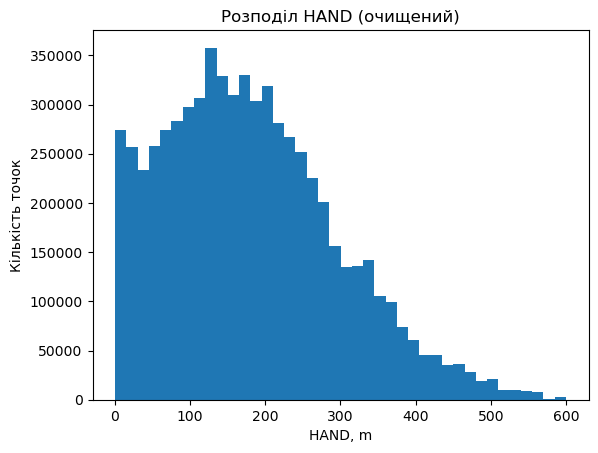

In [8]:
# Фільтр: виключити всі точно 0, або менше 0, або дуже високі HAND
hand_filtered = hand_values[(hand_values > 0) & (hand_values < 600)]

# За бажанням, додати ще умови — наприклад, виключити top-10 найпопулярніших "штучних" значень
popular_vals = hand_values.value_counts().head(10).index
hand_filtered = hand_filtered[~hand_filtered.isin(popular_vals)]

plt.hist(hand_filtered.dropna(), bins=40)
plt.xlabel("HAND, m")
plt.ylabel("Кількість точок")
plt.title("Розподіл HAND (очищений)")
plt.show()


Точок у заплаві (tan_dem_2000 <= 5): 7312083


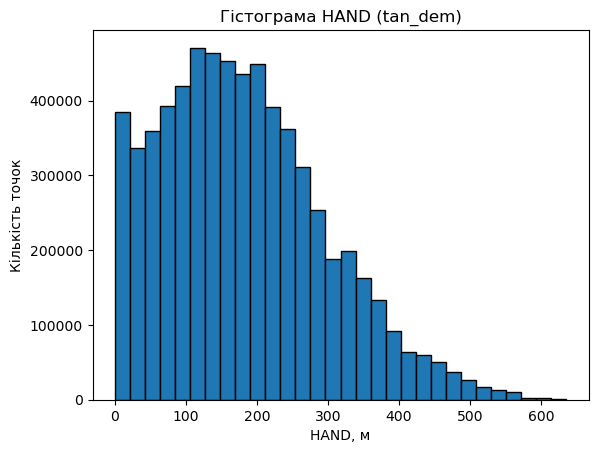

In [9]:
import matplotlib.pyplot as plt
fil = ice_gdf["hand_tan_dem"]
print(f"Точок у заплаві (tan_dem_2000 <= 5): {len(fil)}")

plt.hist(fil.dropna(), bins=30, edgecolor="k")
plt.title("Гістограма HAND (tan_dem)")
plt.xlabel("HAND, м")
plt.ylabel("Кількість точок")
plt.show()


                               region  sc_orient  track  segment_dist  \
2019-10-22 19:56:13.457611264     2.0        1.0    2.0  5.340736e+06   
2019-10-22 19:56:13.457911296     2.0        1.0    2.0  5.340736e+06   
2019-10-22 19:56:13.458111232     2.0        1.0    2.0  5.340736e+06   
2019-10-22 19:56:13.458211328     2.0        1.0    2.0  5.340736e+06   
2019-10-22 19:56:13.458611200     2.0        1.0    2.0  5.340736e+06   
...                               ...        ...    ...           ...   
2024-09-19 18:31:37.639985408     6.0        0.0    3.0  1.474780e+07   
2024-09-19 18:31:37.640685312     6.0        0.0    3.0  1.474780e+07   
2024-09-19 18:31:37.640785152     6.0        0.0    3.0  1.474780e+07   
2024-09-19 18:31:37.642385152     6.0        0.0    3.0  1.474780e+07   
2024-09-19 18:31:37.744185088     6.0        0.0    3.0  1.474856e+07   

                               solar_elevation  segment_id  background_rate  \
2019-10-22 19:56:13.457611264       -44.3507

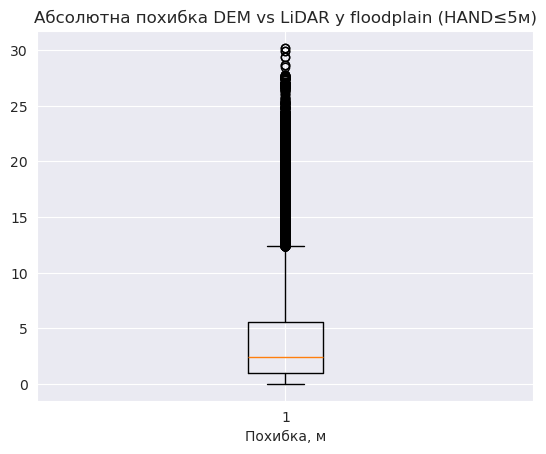

In [27]:
floodplain_5m = ice_gdf[ice_gdf["hand_tan_dem"] <= 5]
print(floodplain_5m)
plt.boxplot(floodplain_5m["abs_delta_tan_dem"].dropna())
plt.title("Абсолютна похибка DEM vs LiDAR у floodplain (HAND≤5м)")
plt.xlabel("Похибка, м")
plt.show()


In [35]:
filtered = ice_gdf[

    (ice_gdf["atl03_cnf"] == 4) &
    (ice_gdf["atl08_class"].isin([1]))
].copy()

In [37]:
filtered

,region,sc_orient,track,segment_dist,solar_elevation,segment_id,background_rate,cycle,pair,rgt,...,h_tan_dem,delta_tan_dem,abs_delta_tan_dem,hand_alos_dem,hand_aster_dem,hand_copernicus_dеm,hand_fab_dem,hand_nasa_dem,hand_srtm_dem,hand_tan_dem
2018-11-04 01:05:32.246215936,6.0,1.0,1.0,1.473420e+07,-40.593658,735621.0,1840.163382,1.0,0.0,556.0,...,1485.023193,2.909004,2.909004,335.00,337.0,343.473877,343.392700,343.581177,348.00,343.473755
2018-11-04 01:05:32.246416128,6.0,1.0,1.0,1.473420e+07,-40.593658,735621.0,1840.163382,1.0,0.0,556.0,...,1485.023193,1.964790,1.964790,335.00,337.0,343.473877,343.392700,343.581177,348.00,343.473755
2018-11-04 01:05:32.247316224,6.0,1.0,1.0,1.473420e+07,-40.593658,735621.0,1840.163382,1.0,0.0,556.0,...,1485.023193,2.532661,2.532661,335.00,339.0,344.161133,344.081665,344.961670,349.00,344.161011
2018-11-04 01:05:32.247916288,6.0,1.0,1.0,1.473420e+07,-40.593658,735621.0,1840.163382,1.0,0.0,556.0,...,1485.023193,2.238228,2.238228,341.00,339.0,344.161133,344.081665,344.961670,349.00,344.161011
2018-11-04 01:05:32.248516096,6.0,1.0,1.0,1.473420e+07,-40.593658,735621.0,1840.163382,1.0,0.0,556.0,...,1485.023193,0.294990,0.294990,341.00,339.0,344.161133,344.081665,344.961670,349.00,344.161011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-19 18:31:37.739285248,6.0,0.0,3.0,1.474850e+07,-21.541277,736332.0,5006.953955,25.0,1.0,53.0,...,997.870361,6.736274,6.736274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-19 18:31:37.739685376,6.0,0.0,3.0,1.474850e+07,-21.541277,736332.0,5006.953955,25.0,1.0,53.0,...,997.870361,6.277656,6.277656,2.38,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-19 18:31:37.740185344,6.0,0.0,3.0,1.474850e+07,-21.541277,736332.0,5006.953955,25.0,1.0,53.0,...,997.870361,3.333076,3.333076,2.38,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-19 18:31:37.766685184,6.0,0.0,3.0,1.474872e+07,-21.542103,736343.0,1668.402299,25.0,1.0,53.0,...,1040.098267,18.925972,18.925972,44.00,39.0,37.261802,21.242615,35.258057,36.38,37.261924


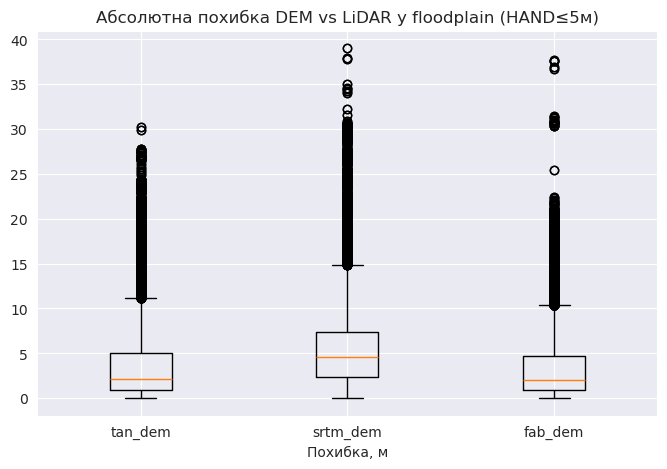

In [38]:
plt.figure(figsize=(8, 5))
data = [
    filtered.loc[filtered["hand_tan_dem"] <= 5, "abs_delta_tan_dem"].dropna(),
    filtered.loc[filtered["hand_srtm_dem"] <= 5, "abs_delta_srtm_dem"].dropna(),
    filtered.loc[filtered["hand_fab_dem"] <= 5, "abs_delta_fab_dem"].dropna(),
]
plt.boxplot(data,  tick_labels=["tan_dem", "srtm_dem", "fab_dem", "copernicus_dеm"])
plt.title("Абсолютна похибка DEM vs LiDAR у floodplain (HAND≤5м)")
plt.xlabel("Похибка, м")
plt.show()

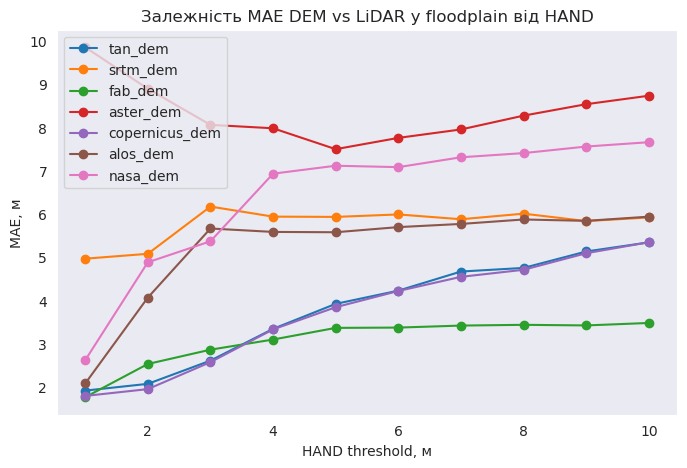

In [41]:
plt.figure(figsize=(8, 5))
thresholds = range(1, 11)
for dem in ["tan_dem", "srtm_dem", "fab_dem", "aster_dem", "copernicus_dеm", "alos_dem", "nasa_dem"]:
    maes = []
    for th in thresholds:
        mask = filtered[f"hand_{dem}"] <= th
        maes.append(filtered.loc[mask, f"abs_delta_{dem}"].mean())
    plt.plot(thresholds, maes, marker='o', label=dem)

plt.title("Залежність MAE DEM vs LiDAR у floodplain від HAND")
plt.xlabel("HAND threshold, м")
plt.ylabel("MAE, м")
plt.legend()
plt.grid()
plt.show()


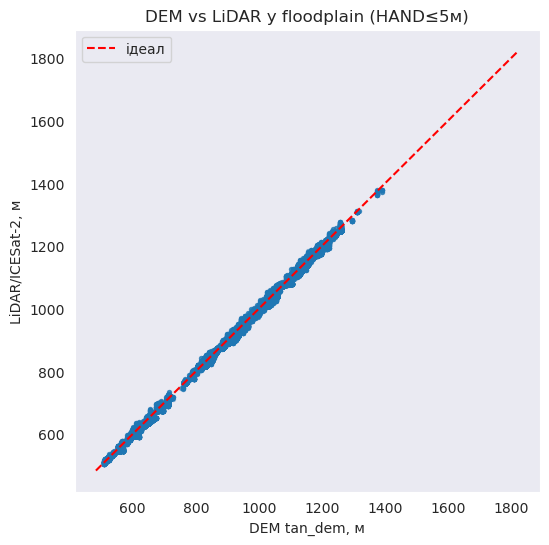

In [44]:
plt.figure(figsize=(6,6))
plt.scatter(
    ice_gdf.loc[ice_gdf["hand_tan_dem"] <= 5, "h_tan_dem"],
    ice_gdf.loc[ice_gdf["hand_tan_dem"] <= 5, "orthometric_height"],
    s=8, alpha=0.5
)
plt.plot(
    [ice_gdf["h_tan_dem"].min(), ice_gdf["h_tan_dem"].max()],
    [ice_gdf["h_tan_dem"].min(), ice_gdf["h_tan_dem"].max()],
    "r--", label="ідеал"
)
plt.xlabel("DEM tan_dem, м")
plt.ylabel("LiDAR/ICESat-2, м")
plt.title("DEM vs LiDAR у floodplain (HAND≤5м)")
plt.legend()
plt.grid()
plt.show()


In [45]:
from sklearn.linear_model import LinearRegression
X = floodplain_5m[["h_tan_dem"]].values
y = floodplain_5m["orthometric_height"].values
model = LinearRegression().fit(X, y)
print("Коефіцієнт лінії:", model.coef_[0])
print("Вільний член (зсув):", model.intercept_)
print("R^2:", model.score(X, y))


Коефіцієнт лінії: 0.9999665566278956
Вільний член (зсув): -2.5913627928790675
R^2: 0.9992185283676841


In [42]:
for dem in ["tan_dem", "srtm_dem", "fab_dem", "aster_dem", "copernicus_dеm", "alos_dem", "nasa_dem"]:
    mask = ice_gdf[f"hand_{dem}"] <= 5
    mae = ice_gdf.loc[mask, f"abs_delta_{dem}"].mean()
    med = ice_gdf.loc[mask, f"abs_delta_{dem}"].median()
    print(f"{dem}: MAE={mae:.2f} м | Median={med:.2f} м | N={mask.sum()}")


tan_dem: MAE=4.18 м | Median=2.42 м | N=85183
srtm_dem: MAE=6.99 м | Median=5.22 м | N=99387
fab_dem: MAE=4.56 м | Median=2.60 м | N=131942
aster_dem: MAE=8.67 м | Median=6.69 м | N=59780
copernicus_dеm: MAE=4.18 м | Median=2.43 м | N=85465
alos_dem: MAE=5.97 м | Median=3.82 м | N=91720
nasa_dem: MAE=7.65 м | Median=5.43 м | N=100025


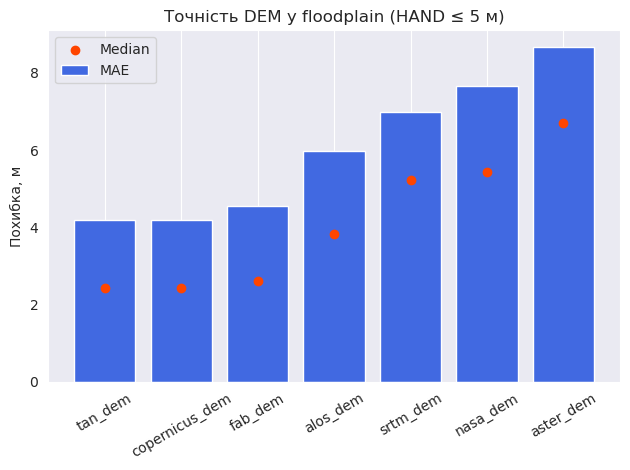

In [46]:
import matplotlib.pyplot as plt

dem_names = ["tan_dem", "copernicus_dem", "fab_dem", "alos_dem", "srtm_dem", "nasa_dem", "aster_dem"]
mae =   [4.18,         4.18,            4.56,      5.97,      6.99,        7.65,      8.67]
median = [2.42,        2.43,            2.60,      3.82,      5.22,        5.43,      6.69]

plt.bar(dem_names, mae, color="royalblue", label="MAE")
plt.scatter(dem_names, median, color="orangered", label="Median", zorder=5)
plt.ylabel("Похибка, м")
plt.title("Точність DEM у floodplain (HAND ≤ 5 м)")
plt.legend()
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.tight_layout()
plt.show()
